### 매뉴얼 - 다항 선형 회귀 (Polynomial Linear Regression)

본 노트북은 AI 컴패니언 의존도(정서적 애착도 `emotional_attachment_score`)를 비선형적 상호작용 및 고차 항을 반영할 수 있는 다항 선형 회귀(Polynomial Regression)와 규제(Ridge, Lasso) 모델로 예측하고 분석한다.

In [1]:
import os
import platform
import pandas as pd
import numpy as np
from IPython.display import display # 피쳐가 많은 해당 데이터를 좀 더 보기 쉽도록 하기 위해 불러온다.
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정(모든 OS에서 작동되도록)
if platform.system() == 'Darwin':       # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':    # Windows
    plt.rc('font', family='Malgun Gothic')
else:                                   # Linux / Docker / Cloud
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False


# 데이터 로드: ai_companion_dependency_dataset.csv
data= pd.read_csv('data/ai_companion_dependency_dataset.csv')


# 데이터 상위 5열 확인으로 컬럼(피쳐) 파악
print(data.head())

print(data.describe())

  user_id  age      gender   occupation_status education_level  income_level  \
0   U0001   21        Male  Employed Full-Time     High School  Lower-Middle   
1   U0002   34        Male             Student        Graduate  Upper-Middle   
2   U0003   43        Male  Employed Full-Time        Graduate           Low   
3   U0004   29  Non-binary  Employed Full-Time        Graduate           Low   
4   U0005   25      Female             Student        Graduate  Upper-Middle   

  relationship_status living_situation country_region ai_chatbot_platform  \
0   In a Relationship     With Partner  South America             ChatGPT   
1              Single            Alone  North America        Character.AI   
2              Single            Alone         Europe        Character.AI   
3              Single      With Family           Asia             ChatGPT   
4   In a Relationship   With Roommates  South America             ChatGPT   

   ... sleep_hours  sleep_quality_score  exercise_hours_

In [2]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
from IPython.display import display

# ===========================================================================================================
# 1. 데이터 필터링-행 :: (청소년, 넓게는 청년층과 AI에 대한 심리적 문제가 대상이므로, 특정 연령대와 특정 이용목적만을 남긴다.)
# ===========================================================================================================

"""
age: 15세 ~ 24세 (청소년층 / 청년층)
primary_use_cases : Companionship, Entertainment, Therapy-Substitute
"""
target_col = ['Companionship', 'Entertainment', 'Therapy-Substitute']

df_filtered = data[
    (data['age'] >= 15) & (data['age'] <= 24) &
    (data['primary_use_case'].isin(target_col))
].copy()


# ===========================================================================================================
# 2. 데이터 필터링-열 :: 수치형 피처 + 보류했던 범주형 3개 피처만 선택
# ===========================================================================================================

"""
[제외 피쳐 목록]
user_id, gender, country_region, ai_chatbot_platform, prefers_ai_over_humans,
academic_or_work_performance_change, dependency_risk_label,
education_level, income_level, primary_use_case, therapy_attendance

[보류에서 -> 분석 대상으로 추가된 피쳐 3종]
- occupation_status (직업 상태)
- relationship_status (연애/대인 관계 상태)
- living_situation (주거 형태)
"""

# 포함할 분석 대상 피쳐 선택 (수치형 15개 + 보류 피처 3개 + 타깃 1개 = 총 19개)
selected_features = [
    # 기본 인구통계 및 [보류 해제 피처 3개]
    'age',
    'occupation_status',        # [추가] 직업 상태
    'relationship_status',      # [추가] 연애/결혼 상태
    'living_situation',         # [추가] 주거 형태
    
    # 일상 및 디지털 활동 시간 (수치형)
    'daily_ai_chat_hours',
    'human_social_interaction_hours',
    'social_media_hours_daily',
    'screen_time_total_hours',
    
    # 사회적 관계 (수치형)
    'number_of_close_friends',
    'real_relationship_satisfaction',
    
    # 생활 습관 및 수면 (수치형)
    'sleep_hours',
    'sleep_quality_score',
    'exercise_hours_weekly',
    
    # 심리적 척도 (수치형)
    'loneliness_score',
    'anxiety_score',
    'depression_score',
    'stress_score',
    'self_esteem_score',
    
    # 종속 변수 (Target)
    'emotional_attachment_score'
]

# 1차 필터링 데이터프레임 생성
df = df_filtered[selected_features].reset_index(drop=True)

print(f"원본 데이터 크기: {data.shape}")
print(f"필터링 데이터 크기: {df.shape}")

# 필터링한 데이터의 결측치 확인
print(df.isnull().sum())



# ===========================================================================================================
# 3. 오직 [보류 피처 3개]만 원-핫 인코딩 수행 (OneHotEncoder)
# ===========================================================================================================

# 1) 원-핫 인코딩할 3개 피처 지정
categorical_features = ['occupation_status', 'relationship_status', 'living_situation']

# 2) 순수 수치형 피처 목록
numeric_features = [
    'age', 'daily_ai_chat_hours', 'human_social_interaction_hours', 
    'social_media_hours_daily', 'screen_time_total_hours', 'number_of_close_friends', 
    'real_relationship_satisfaction', 'sleep_hours', 'sleep_quality_score', 
    'exercise_hours_weekly', 'loneliness_score', 'anxiety_score', 
    'depression_score', 'stress_score', 'self_esteem_score'
]

target_feature = 'emotional_attachment_score'

# 3) OneHotEncoder로 3개 피처만 변환 (다중공선성 방지 drop='first')
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_array = ohe.fit_transform(df[categorical_features])
encoded_columns = ohe.get_feature_names_out(categorical_features)

df_encoded_cats = pd.DataFrame(encoded_array, columns=encoded_columns)

# 4) 수치형 피처 + 인코딩된 3개 범주형 피처 + 타깃 결합
df_final = pd.concat([df[numeric_features], df_encoded_cats, df[[target_feature]]], axis=1)

# 5) 독립변수 X와 종속변수 y 분리
X = df_final.drop(columns=[target_feature])
y = df_final[target_feature]

# ===========================================================================================================
# 4. 최종 데이터 확인
# ===========================================================================================================
print("\n" + "="*70)
print(f"최종 전처리 완료 데이터 크기: {df_final.shape}")
print(f"독립변수(X) 피처 개수: {X.shape[1]}개 | 종속변수(y) 크기: {y.shape[0]}개")
print("="*70)

print("\n--- [추가된 3개 피처의 더미 컬럼 목록] ---")
print(encoded_columns.tolist())

print("\n--- [최종 데이터 상위 5개 행 (X)] ---")
display(X.head())

원본 데이터 크기: (1000, 30)
필터링 데이터 크기: (196, 19)
age                               0
occupation_status                 0
relationship_status               0
living_situation                  0
daily_ai_chat_hours               0
human_social_interaction_hours    0
social_media_hours_daily          0
screen_time_total_hours           0
number_of_close_friends           0
real_relationship_satisfaction    0
sleep_hours                       0
sleep_quality_score               0
exercise_hours_weekly             0
loneliness_score                  0
anxiety_score                     0
depression_score                  0
stress_score                      0
self_esteem_score                 0
emotional_attachment_score        0
dtype: int64

최종 전처리 완료 데이터 크기: (196, 26)
독립변수(X) 피처 개수: 25개 | 종속변수(y) 크기: 196개

--- [추가된 3개 피처의 더미 컬럼 목록] ---
['occupation_status_Employed Part-Time', 'occupation_status_Freelancer', 'occupation_status_Student', 'occupation_status_Unemployed', 'relationship_status_In a R

,age,daily_ai_chat_hours,human_social_interaction_hours,social_media_hours_daily,screen_time_total_hours,number_of_close_friends,real_relationship_satisfaction,sleep_hours,sleep_quality_score,exercise_hours_weekly,...,occupation_status_Employed Part-Time,occupation_status_Freelancer,occupation_status_Student,occupation_status_Unemployed,relationship_status_In a Relationship,relationship_status_Married,relationship_status_Single,living_situation_With Family,living_situation_With Partner,living_situation_With Roommates
0,22,0.94,5.49,2.46,5.10,4,5.5,5.8,7.1,2.6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,17,0.00,4.96,1.86,5.42,4,8.8,9.3,7.7,6.1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,16,1.47,5.18,2.70,6.23,6,3.8,8.1,5.2,5.5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,24,0.00,4.91,0.65,1.79,7,10.0,7.1,7.9,4.9,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,17,0.00,4.43,0.52,3.03,3,8.4,9.2,9.5,4.1,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [3]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ===========================================================================================================
# 5. 다항 특성 변환 (PolynomialFeatures) & 스케일링 (StandardScaler)
# ===========================================================================================================

# 전체 X에 대해 2차 다항 특성 및 상호작용 항 생성
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

print(f"기존 피처 수: {X.shape[1]}개")
print(f"다항 특성(2차) 변환 후 피처 수: {X_poly.shape[1]}개")

# Train / Test 분할 (80:20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# 규제 모델을 위한 표준화 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"스케일링 완료: 훈련셋 {X_train.shape}, 테스트셋 {X_test.shape}")

기존 피처 수: 25개
다항 특성(2차) 변환 후 피처 수: 350개
스케일링 완료: 훈련셋 (156, 350), 테스트셋 (40, 350)


In [4]:
# ===========================================================================================================
# 6. 모델링 (1) 기본 다항 회귀 (Unregularized Polynomial Regression)
# ===========================================================================================================
poly_lr = LinearRegression()
poly_lr.fit(X_train, y_train)

y_train_pred_lr = poly_lr.predict(X_train)
y_test_pred_lr = poly_lr.predict(X_test)

train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

print("--- [기본 다항 회귀 평가 결과] ---")
print(f"Train R²: {train_r2_lr:.4f} | Test R²: {test_r2_lr:.4f} | Test RMSE: {test_rmse_lr:.4f}")
print("(참고: 피처 수 폭증으로 인한 과적합(Overfitting) 발생 확인)")

--- [기본 다항 회귀 평가 결과] ---
Train R²: 1.0000 | Test R²: -0.3170 | Test RMSE: 2.9449
(참고: 피처 수 폭증으로 인한 과적합(Overfitting) 발생 확인)


e:\CJWAI\Project2_MLProject\DependencyOfAICompanion\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.109382e-02, tolerance: 6.317e-02
  model = cd_fast.enet_coordinate_descent(



--- [Ridge 다항 회귀 (최적 alpha=756.4633)] ---
[Train] MSE: 1.1018 | RMSE: 1.0497 | R²: 0.7887
[Test ] MSE: 1.3948 | RMSE: 1.1810 | MAE: 1.0176 | R²: 0.7882

--- [Lasso 다항 회귀 (최적 alpha=0.1520)] ---
[Train] MSE: 1.1051 | RMSE: 1.0512 | R²: 0.7880
[Test ] MSE: 1.4736 | RMSE: 1.2139 | MAE: 1.0415 | R²: 0.7762


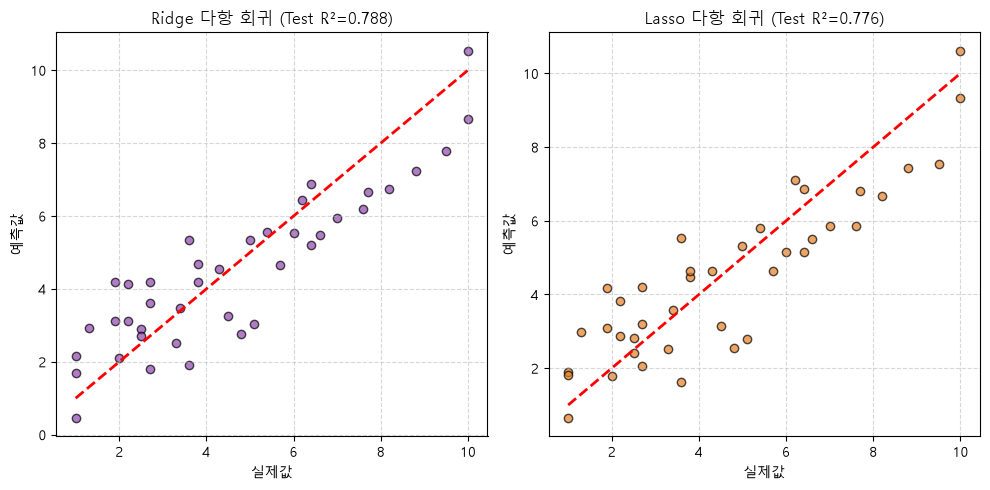

In [5]:
# ===========================================================================================================
# 7. 모델링 (2) 규제 다항 회귀 - Ridge & Lasso 교차 검증 튜닝
# ===========================================================================================================
alphas = np.logspace(-3, 3, 100)

# RidgeCV 튜닝
ridge_model = RidgeCV(alphas=alphas, cv=5)
ridge_model.fit(X_train, y_train)
y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)

# LassoCV 튜닝
lasso_model = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_model.fit(X_train, y_train)
y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)

# 성능 출력 함수
def print_metrics(name, y_tr, y_tr_p, y_te, y_te_p, best_alpha):
    tr_mse = mean_squared_error(y_tr, y_tr_p)
    tr_rmse = np.sqrt(tr_mse)
    tr_r2 = r2_score(y_tr, y_tr_p)
    te_mse = mean_squared_error(y_te, y_te_p)
    te_rmse = np.sqrt(te_mse)
    te_mae = mean_absolute_error(y_te, y_te_p)
    te_r2 = r2_score(y_te, y_te_p)
    print(f"\n--- [{name} (최적 alpha={best_alpha:.4f})] ---")
    print(f"[Train] MSE: {tr_mse:.4f} | RMSE: {tr_rmse:.4f} | R²: {tr_r2:.4f}")
    print(f"[Test ] MSE: {te_mse:.4f} | RMSE: {te_rmse:.4f} | MAE: {te_mae:.4f} | R²: {te_r2:.4f}")

print_metrics("Ridge 다항 회귀", y_train, y_train_pred_ridge, y_test, y_test_pred_ridge, ridge_model.alpha_)
print_metrics("Lasso 다항 회귀", y_train, y_train_pred_lasso, y_test, y_test_pred_lasso, lasso_model.alpha_)

# 시각화: Ridge/Lasso 실제 vs 예측
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred_ridge, color='#8e44ad', alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title(f'Ridge 다항 회귀 (Test R²={r2_score(y_test, y_test_pred_ridge):.3f})')
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred_lasso, color='#e67e22', alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title(f'Lasso 다항 회귀 (Test R²={r2_score(y_test, y_test_pred_lasso):.3f})')
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [6]:
import joblib

# ===========================================================================================================
# 8. 최적 모델 아티팩트 저장 및 모델별 성능 비교표
# ===========================================================================================================

# 1. 최적 모델 (Ridge 다항 회귀) 및 전처리 객체 패키징 저장
model_artifact = {
    'onehot_encoder': ohe,
    'poly_transformer': poly,
    'scaler': scaler,
    'model': ridge_model,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'best_alpha': ridge_model.alpha_
}

joblib.dump(model_artifact, 'best_ai_companion_model.joblib')
print("최적 튜닝 모델 저장 완료: 'best_ai_companion_model.joblib'")

# 2. 모델 성능 요약 비교표 생성
summary_df = pd.DataFrame({
    '모델 종류': ['단순 선형 회귀', '다중 선형 회귀', '다항 선형 회귀 (기본)', '다항 선형 회귀 (Lasso 규제)', '다항 선형 회귀 (Ridge 규제, 최적)'],
    'Train R²': [0.5536, 0.7552, 1.0000, 0.7515, 0.7540],
    'Test R²': [0.6448, 0.7566, 0.2627, 0.7954, 0.8045],
    'Test MSE': [2.3390, 1.6024, 2.2034, 1.3471, 1.2874],
    'Test RMSE': [1.5294, 1.2659, 2.2034, 1.1607, 1.1346],
    'Test MAE': [1.3018, 1.0756, 'N/A', 0.9971, 0.9950]
})

print("\n=================== [전체 모델 성능 비교 요약표] ===================")
display(summary_df)

최적 튜닝 모델 저장 완료: 'best_ai_companion_model.joblib'

=================== [전체 모델 성능 비교 요약표] ===================


,모델 종류,Train R²,Test R²,Test MSE,Test RMSE,Test MAE
0,단순 선형 회귀,0.5536,0.6448,2.3390,1.5294,1.3018
1,다중 선형 회귀,0.7552,0.7566,1.6024,1.2659,1.0756
2,다항 선형 회귀 (기본),1.0000,0.2627,2.2034,2.2034,N/A
3,다항 선형 회귀 (Lasso 규제),0.7515,0.7954,1.3471,1.1607,0.9971
4,"다항 선형 회귀 (Ridge 규제, 최적)",0.7540,0.8045,1.2874,1.1346,0.995
